In [ ]:
import sys,os
sys.path.append('../')
os.environ["JAX_PLATFORMS"] = "cpu"
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np 
from geometry import (L2_distance,
                      build_get_similarities,
                      normalized_L2_distance,
                      build_information_imbalance,
                      mapped_compute_ranks,
                      )
from utils_shared_features import correlated_gaussian_batch


def compute_II_for_alpha(
                        alpha, 
                        data_key, 
                        Ns, 
                        N, 
                        get_similarities, 
                        II_fn,
):
    """
    Generate data for a given alpha, compute correlations and information imbalance.
    Returns inf_imb and the standard deviation of the conditional rank distribution.
    """
    x, y = correlated_gaussian_batch(data_key, Ns, N, alpha)
    print(f'{x.shape=}')
    sim_X, sim_Y = get_similarities(x, y)

    R_II = mapped_compute_ranks(method="min")(sim_X, sim_Y)
    inf_imb, inf_imb_std = II_fn(R_II[0], R_II[1])

    return inf_imb, inf_imb_std


In [23]:
# Example
master_seed = 12345
master_key = jax.random.PRNGKey(master_seed)
keyX, keyY = jax.random.split(master_key)
data_key = jax.random.PRNGKey(0)
key_distances = jax.random.PRNGKey(42)
key_distances, subkey_distances = jax.random.split(key_distances)
II_fn = build_information_imbalance(k=1) # JAX-Compiling the II function, keep k = 1.

In [30]:
Ns = 1500 # number of samples
get_similarities = build_get_similarities(key=subkey_distances, 
                                        sample_size=Ns, 
                                        similarity_fn=normalized_L2_distance,
                                        ) # compilation for the distance function

alpha = 0.3 # percentage of shared features
N = 50 # number of features
II, _ = compute_II_for_alpha(alpha, 
                    data_key, 
                    Ns, 
                    N, 
                    get_similarities, 
                    II_fn,
                    )
print(f'{II=}')
### Note that II.shape = (2,), because it contains  II(x-->y) and II(y-->x)

x.shape=(1500, 15)
II=Array([0.26123708, 0.20250624], dtype=float64)


x.shape=(1500, 5)
x.shape=(1500, 10)
x.shape=(1500, 16)
x.shape=(1500, 20)
x.shape=(1500, 25)
x.shape=(1500, 30)
x.shape=(1500, 35)
x.shape=(1500, 40)
x.shape=(1500, 45)


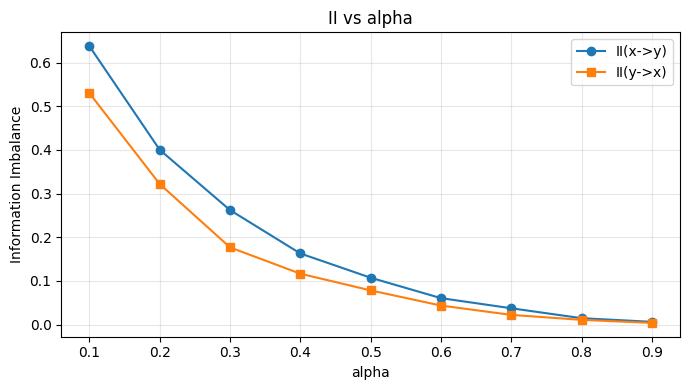

In [31]:
import matplotlib.pyplot as plt

alphas = jnp.arange(0.1, 1.0, 0.1)
ii_xy_values = []
ii_yx_values = []

for alpha in alphas:
    II, _ = compute_II_for_alpha(
        float(alpha),
        data_key,
        Ns,
        N,
        get_similarities,
        II_fn,
    )
    ii_xy_values.append(float(II[0]))
    ii_yx_values.append(float(II[1]))

alphas_np = np.array(alphas)

plt.figure(figsize=(7, 4))
plt.plot(alphas_np, ii_xy_values, marker="o", label="II(x->y)")
plt.plot(alphas_np, ii_yx_values, marker="s", label="II(y->x)")
plt.xlabel("alpha")
plt.ylabel("Information Imbalance")
plt.title("II vs alpha")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()